Propagating SSO for 30 days...

  RAAN EVOLUTION IN SSO ORBIT
Initial RAAN (t=0):        0.000 deg
RAAN after 24 hours (t=1d):   0.990 deg  (+ ~1 deg)
RAAN after 30 days (t=30d): 29.630 deg  (+ ~30 deg)

Generating 3D plot...


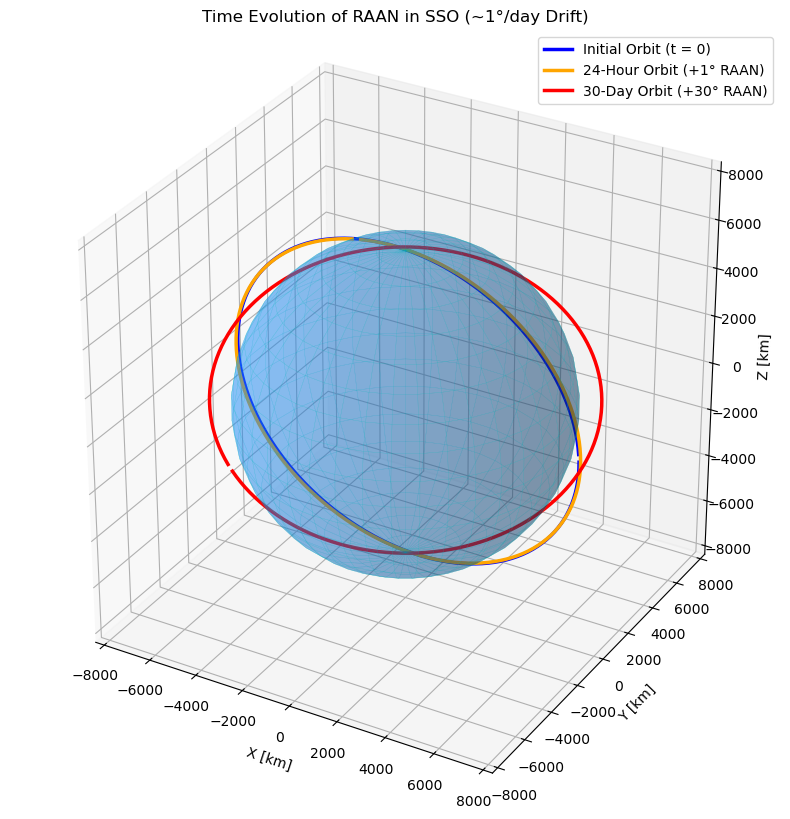

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
import orekit
from orekit.pyhelpers import setup_orekit_curdir
from orekit import JArray_double

# ==========================================
# 1. OREKIT ENVIRONMENT INITIALIZATION
# ==========================================
orekit.initVM()
setup_orekit_curdir('C:/Users/Simone/Downloads/orekit-data-main')

from org.orekit.orbits import KeplerianOrbit, PositionAngleType
from org.orekit.frames import FramesFactory
from org.orekit.time import TimeScalesFactory, AbsoluteDate
from org.orekit.utils import Constants, IERSConventions
from org.orekit.propagation.numerical import NumericalPropagator
from org.hipparchus.ode.nonstiff import DormandPrince853Integrator
from org.orekit.propagation import SpacecraftState
from org.orekit.forces.gravity.potential import GravityFieldFactory
from org.orekit.forces.gravity import HolmesFeatherstoneAttractionModel

# ==========================================
# 2. TIME AND FRAMES DEFINITION
# ==========================================
utc = TimeScalesFactory.getUTC()
initial_date = AbsoluteDate(2026, 8, 4, 12, 0, 0.0, utc)

inertial_frame = FramesFactory.getEME2000()
earth_frame = FramesFactory.getITRF(IERSConventions.IERS_2010, True)
mu = Constants.WGS84_EARTH_MU

# ==========================================
# 3. ORBIT CREATION (SSO at 800 km)
# ==========================================
h = 800e3
a = Constants.WGS84_EARTH_EQUATORIAL_RADIUS + h  # 800 km
e = 0.001
i = math.radians(98.6)  # SSO Inclination
omega = math.radians(0.0)
raan = math.radians(0.0)
lM = math.radians(0.0)

initial_orbit = KeplerianOrbit(a, e, i, omega, raan, lM, PositionAngleType.MEAN, inertial_frame, initial_date, mu)
initial_state = SpacecraftState(initial_orbit, 850.0)

# ==========================================
# 4. PROPAGATOR CONFIGURATION
# ==========================================
min_step = 0.001
max_step = 300.0
position_tolerance = 10.0 
tolerances = NumericalPropagator.tolerances(position_tolerance, initial_orbit, initial_orbit.getType())
abs_tolerance = JArray_double.cast_(tolerances[0])
rel_tolerance = JArray_double.cast_(tolerances[1])

integrator = DormandPrince853Integrator(min_step, max_step, abs_tolerance, rel_tolerance)
propagator = NumericalPropagator(integrator)
propagator.setInitialState(initial_state)

ephemeris_generator = propagator.getEphemerisGenerator()

# Add gravity field for the J2 effect
gravity_provider = GravityFieldFactory.getNormalizedProvider(4, 4)
propagator.addForceModel(HolmesFeatherstoneAttractionModel(earth_frame, gravity_provider))

# ==========================================
# 5. PROPAGATION (30 DAYS)
# ==========================================
days = 30.0
duration = days * 24.0 * 3600.0  
final_date = initial_date.shiftedBy(duration)

print(f"Propagating SSO for {int(days)} days...")
final_state = propagator.propagate(final_date)

# Retrieve 24-hour orbit using the ephemeris
ephemeris = ephemeris_generator.getGeneratedEphemeris()
state_24h = ephemeris.propagate(initial_date.shiftedBy(24.0 * 3600.0))

orbit_24h = KeplerianOrbit(state_24h.getOrbit())
orbit_30d = KeplerianOrbit(final_state.getOrbit())

# ==========================================
# 6. RESULTS (RAAN Comparison)
# ==========================================
raan_24h = math.degrees(orbit_24h.getRightAscensionOfAscendingNode())
raan_30d = math.degrees(orbit_30d.getRightAscensionOfAscendingNode())

print("\n========================================================")
print("  RAAN EVOLUTION IN SSO ORBIT")
print("========================================================")
print(f"Initial RAAN (t=0):        {math.degrees(raan):.3f} deg")
print(f"RAAN after 24 hours (t=1d):   {raan_24h:.3f} deg  (+ ~1 deg)")
print(f"RAAN after {int(days)} days (t=30d): {raan_30d:.3f} deg  (+ ~30 deg)")
print("========================================================\n")

# ==========================================
# 7. 3D VISUALIZATION (3 SNAPSHOTS OVER TIME)
# ==========================================
print("Generating 3D plot...")
orbital_period = 6000.0  # An 800 km orbit takes about 100 minutes

# Function to extract 1 orbit at a given time instance
def extract_orbit(start_time, end_time):
    times = np.linspace(start_time, end_time, 150)
    x, y, z = [], [], []
    for t in times:
        current_date = initial_date.shiftedBy(float(t))
        pos = ephemeris.propagate(current_date).getPVCoordinates().getPosition()
        x.append(pos.getX() / 1000.0)
        y.append(pos.getY() / 1000.0)
        z.append(pos.getZ() / 1000.0)
    return x, y, z

# Extracting the 3 revolutions
x0, y0, z0 = extract_orbit(0, orbital_period)                                   # Initial Revolution
x1, y1, z1 = extract_orbit(86400, 86400 + orbital_period)                       # After 1 Day
x30, y30, z30 = extract_orbit(duration - orbital_period, duration)              # After 30 Days

fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')

# Draw the Earth
u, v = np.mgrid[0:2*np.pi:40j, 0:np.pi:20j]
R_E_km = Constants.WGS84_EARTH_EQUATORIAL_RADIUS / 1000.0
x_earth = R_E_km * np.cos(u) * np.sin(v)
y_earth = R_E_km * np.sin(u) * np.sin(v)
z_earth = R_E_km * np.cos(v)
ax.plot_surface(x_earth, y_earth, z_earth, color='dodgerblue', alpha=0.3, edgecolor='c', linewidth=0.2)

# Plotting the 3 orbits
ax.plot(x0, y0, z0, color='blue', linewidth=2.5, label='Initial Orbit (t = 0)')
ax.plot(x1, y1, z1, color='orange', linewidth=2.5, label='24-Hour Orbit (+1° RAAN)')
ax.plot(x30, y30, z30, color='red', linewidth=2.5, label='30-Day Orbit (+30° RAAN)')

lim = R_E_km + 2000
ax.set_xlim([-lim, lim]); ax.set_ylim([-lim, lim]); ax.set_zlim([-lim, lim])
ax.set_box_aspect([1,1,1]) 

ax.set_xlabel('X [km]'); ax.set_ylabel('Y [km]'); ax.set_zlabel('Z [km]')
ax.set_title('Time Evolution of RAAN in SSO (~1°/day Drift)')
ax.legend(loc='upper right')

plt.show()